In [1]:
# Install required packages
%pip install tensorflow numpy matplotlib seaborn scikit-learn pandas

# Vanilla RNN Model for Time Series Prediction with TensorFlow/Keras

This notebook implements a Vanilla RNN (Recurrent Neural Network) using TensorFlow/Keras for time series prediction using synthetic sine wave data.

## Objectives:
- Generate and preprocess synthetic time series data
- Build the Vanilla RNN model architecture for sequence prediction
- Train with different optimizers (SGD, Adam, RMSProp)
- Apply regularization techniques (Dropout, L1/L2, EarlyStopping)
- Perform basic hyperparameter tuning
- Visualize training curves and prediction results
- Evaluate model performance
- Save the trained model

In [2]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import os
from collections import Counter

In [3]:
# Dataset Generation Function
def generate_time_series_data(seq_length=100, num_samples=1000):
    """
    Generate synthetic time series data using sine waves
    """
    print("Generating synthetic time series data...")

    # Generate time steps
    t = np.linspace(0, 50, seq_length * num_samples)

    # Create sine wave with noise
    data = np.sin(0.1 * t) + 0.1 * np.sin(0.5 * t) + 0.05 * np.random.randn(len(t))

    # Reshape into sequences
    sequences = []
    targets = []

    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        targets.append(data[i+seq_length])

    sequences = np.array(sequences)
    targets = np.array(targets)

    return sequences, targets

# Generate the dataset
sequences, targets = generate_time_series_data()
print("Dataset generated successfully!")

Generating synthetic time series data...
Dataset generated successfully!


Dataset Info:
Sequences shape: (99900, 100)
Targets shape: (99900,)

Data type: float64
Target type: float64

Statistical Summary:
Sequence mean: 0.1438
Sequence std: 0.7225
Sequence min: -1.2746
Sequence max: 1.2779
Target mean: 0.1433
Target std: 0.7230
Target min: -1.2746
Target max: 1.2779


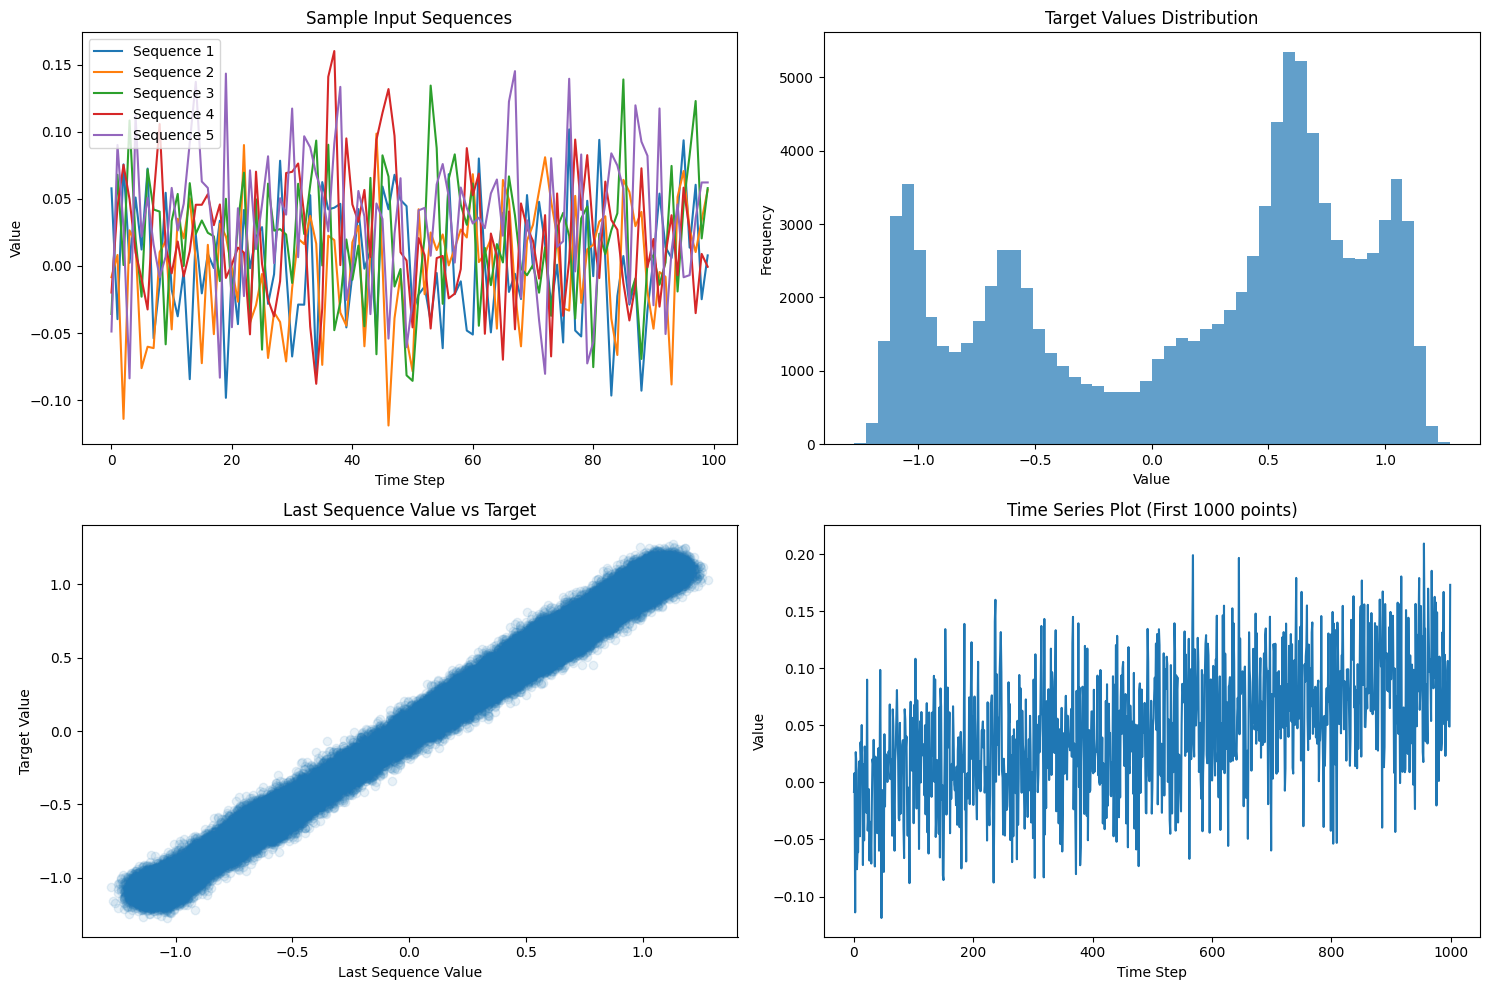

In [4]:
# Dataset Exploration
def explore_time_series_data(sequences, targets):
    """
    Display dataset shape, sample data, and statistical analysis
    """
    print("Dataset Info:")
    print(f"Sequences shape: {sequences.shape}")
    print(f"Targets shape: {targets.shape}")

    print(f"\nData type: {sequences.dtype}")
    print(f"Target type: {targets.dtype}")

    # Statistical summary
    print("\nStatistical Summary:")
    print(f"Sequence mean: {np.mean(sequences):.4f}")
    print(f"Sequence std: {np.std(sequences):.4f}")
    print(f"Sequence min: {np.min(sequences):.4f}")
    print(f"Sequence max: {np.max(sequences):.4f}")

    print(f"Target mean: {np.mean(targets):.4f}")
    print(f"Target std: {np.std(targets):.4f}")
    print(f"Target min: {np.min(targets):.4f}")
    print(f"Target max: {np.max(targets):.4f}")

    # Sample data visualization
    plt.figure(figsize=(15, 10))

    # Plot sample sequences
    plt.subplot(2, 2, 1)
    for i in range(5):
        plt.plot(sequences[i*100], label=f'Sequence {i+1}')
    plt.title('Sample Input Sequences')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()

    # Plot targets distribution
    plt.subplot(2, 2, 2)
    plt.hist(targets, bins=50, alpha=0.7)
    plt.title('Target Values Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

    # Plot sequence vs target relationship
    plt.subplot(2, 2, 3)
    plt.scatter(sequences[:, -1], targets, alpha=0.1)
    plt.title('Last Sequence Value vs Target')
    plt.xlabel('Last Sequence Value')
    plt.ylabel('Target Value')

    # Plot autocorrelation
    plt.subplot(2, 2, 4)
    from pandas.plotting import autocorrelation_plot
    pd.Series(targets[:1000]).plot()
    plt.title('Time Series Plot (First 1000 points)')
    plt.xlabel('Time Step')
    plt.ylabel('Value')

    plt.tight_layout()
    plt.show()

# Explore the dataset
explore_time_series_data(sequences, targets)

In [5]:
# Preprocessing
def preprocess_time_series_data(sequences, targets):
    """
    Preprocess time series data: normalize, split train/val/test
    """
    # Normalize data
    seq_mean = np.mean(sequences)
    seq_std = np.std(sequences)

    sequences_normalized = (sequences - seq_mean) / seq_std
    targets_normalized = (targets - seq_mean) / seq_std

    # Split into train, validation, and test sets
    total_samples = len(sequences_normalized)
    train_size = int(0.7 * total_samples)
    val_size = int(0.15 * total_samples)

    train_X = sequences_normalized[:train_size]
    train_y = targets_normalized[:train_size]

    val_X = sequences_normalized[train_size:train_size + val_size]
    val_y = targets_normalized[train_size:train_size + val_size]

    test_X = sequences_normalized[train_size + val_size:]
    test_y = targets_normalized[train_size + val_size:]

    return (train_X, train_y), (val_X, val_y), (test_X, test_y), seq_mean, seq_std

# Preprocess data
(train_X, train_y), (val_X, val_y), (test_X, test_y), data_mean, data_std = preprocess_time_series_data(
    sequences, targets
)

print(f"Training data shape: {train_X.shape}")
print(f"Validation data shape: {val_X.shape}")
print(f"Test data shape: {test_X.shape}")
print(f"Data mean: {data_mean:.4f}, Data std: {data_std:.4f}")

Training data shape: (69930, 100)
Validation data shape: (14985, 100)
Test data shape: (14985, 100)
Data mean: 0.1438, Data std: 0.7225


In [6]:
# Build Vanilla RNN Model
def build_vanilla_rnn_model(input_shape, rnn_units=32):
    """
    Build Vanilla RNN model for time series prediction with regularization
    """
    model = keras.Sequential([
        layers.SimpleRNN(rnn_units, input_shape=input_shape,
                        kernel_regularizer=keras.regularizers.l2(0.01),
                        recurrent_regularizer=keras.regularizers.l2(0.01),
                        return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l1_l2(l1=0.01, l2=0.01)),
        layers.Dropout(0.2),
        layers.Dense(1)  # Regression output
    ])

    return model

# Build model
input_shape = (train_X.shape[1], 1)  # (sequence_length, features)
model = build_vanilla_rnn_model(input_shape)

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Training with Different Optimizers
def train_with_optimizer(model, optimizer_name, train_X, train_y, val_X, val_y, epochs=20):
    """
    Train model with specified optimizer and regularization
    """
    if optimizer_name == 'SGD':
        optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = keras.optimizers.Adam(learning_rate=0.001)
    elif optimizer_name == 'RMSProp':
        optimizer = keras.optimizers.RMSprop(learning_rate=0.001)

    model.compile(optimizer=optimizer,
                  loss='mse',
                  metrics=['mae'])

    # Early stopping
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(train_X, train_y,
                       validation_data=(val_X, val_y),
                       epochs=epochs,
                       batch_size=32,
                       callbacks=[early_stopping],
                       verbose=1)

    return history

# Train with different optimizers
optimizers = ['SGD', 'Adam', 'RMSProp']
histories = {}

for opt in optimizers:
    print(f"\nTraining with {opt} optimizer...")
    model_copy = build_vanilla_rnn_model(input_shape)
    history = train_with_optimizer(model_copy, opt, train_X, train_y, val_X, val_y)
    histories[opt] = history
    print(f"{opt} training completed.")


Training with SGD optimizer...
Epoch 1/20
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 0.1548 - mae: 0.1424 - val_loss: 0.3202 - val_mae: 0.5193
Epoch 2/20
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0644 - mae: 0.1378 - val_loss: 0.3134 - val_mae: 0.5172
Epoch 3/20
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0623 - mae: 0.1371 - val_loss: 0.3622 - val_mae: 0.5661
Epoch 4/20
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0614 - mae: 0.1372 - val_loss: 0.4282 - val_mae: 0.6215
Epoch 5/20
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0617 - mae: 0.1371 - val_loss: 0.4065 - val_mae: 0.6047
Epoch 6/20
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0608 - mae: 0.1360 - val_loss: 0.2763 - val_mae: 0.4826
Epoch 7/20
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0619 - mae: 0.1367 - val_loss: 0.2075 - val_mae: 0.4056
Epoch 8/20
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0628 - mae: 0.1362 - val_loss: 0.2356 - val_mae: 0.4417


In [8]:
# Hyperparameter Tuning (Basic)
def hyperparameter_tuning(train_X, train_y, val_X, val_y):
    """
    Basic hyperparameter tuning for RNN units and learning rate
    """
    best_model = None
    best_val_loss = float('inf')
    best_params = {}

    rnn_units_list = [16, 32, 64]
    learning_rates = [0.001, 0.01]

    for rnn_units in rnn_units_list:
        for lr in learning_rates:
            print(f"\nTuning: rnn_units={rnn_units}, learning_rate={lr}")

            model = build_vanilla_rnn_model(input_shape, rnn_units=rnn_units)
            model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                         loss='mse',
                         metrics=['mae'])

            early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

            history = model.fit(train_X, train_y,
                               validation_data=(val_X, val_y),
                               epochs=10,
                               batch_size=32,
                               callbacks=[early_stopping],
                               verbose=0)

            val_loss = min(history.history['val_loss'])

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = model
                best_params = {'rnn_units': rnn_units, 'learning_rate': lr}

    print(f"\nBest hyperparameters: {best_params}")
    print(f"Best validation loss: {best_val_loss}")

    return best_model, best_params

# Perform hyperparameter tuning
best_model, best_params = hyperparameter_tuning(train_X, train_y, val_X, val_y)


Tuning: rnn_units=16, learning_rate=0.001

Tuning: rnn_units=16, learning_rate=0.01

Tuning: rnn_units=32, learning_rate=0.001

Tuning: rnn_units=32, learning_rate=0.01

Tuning: rnn_units=64, learning_rate=0.001

Tuning: rnn_units=64, learning_rate=0.01

Best hyperparameters: {'rnn_units': 16, 'learning_rate': 0.01}
Best validation loss: 0.0390658974647522


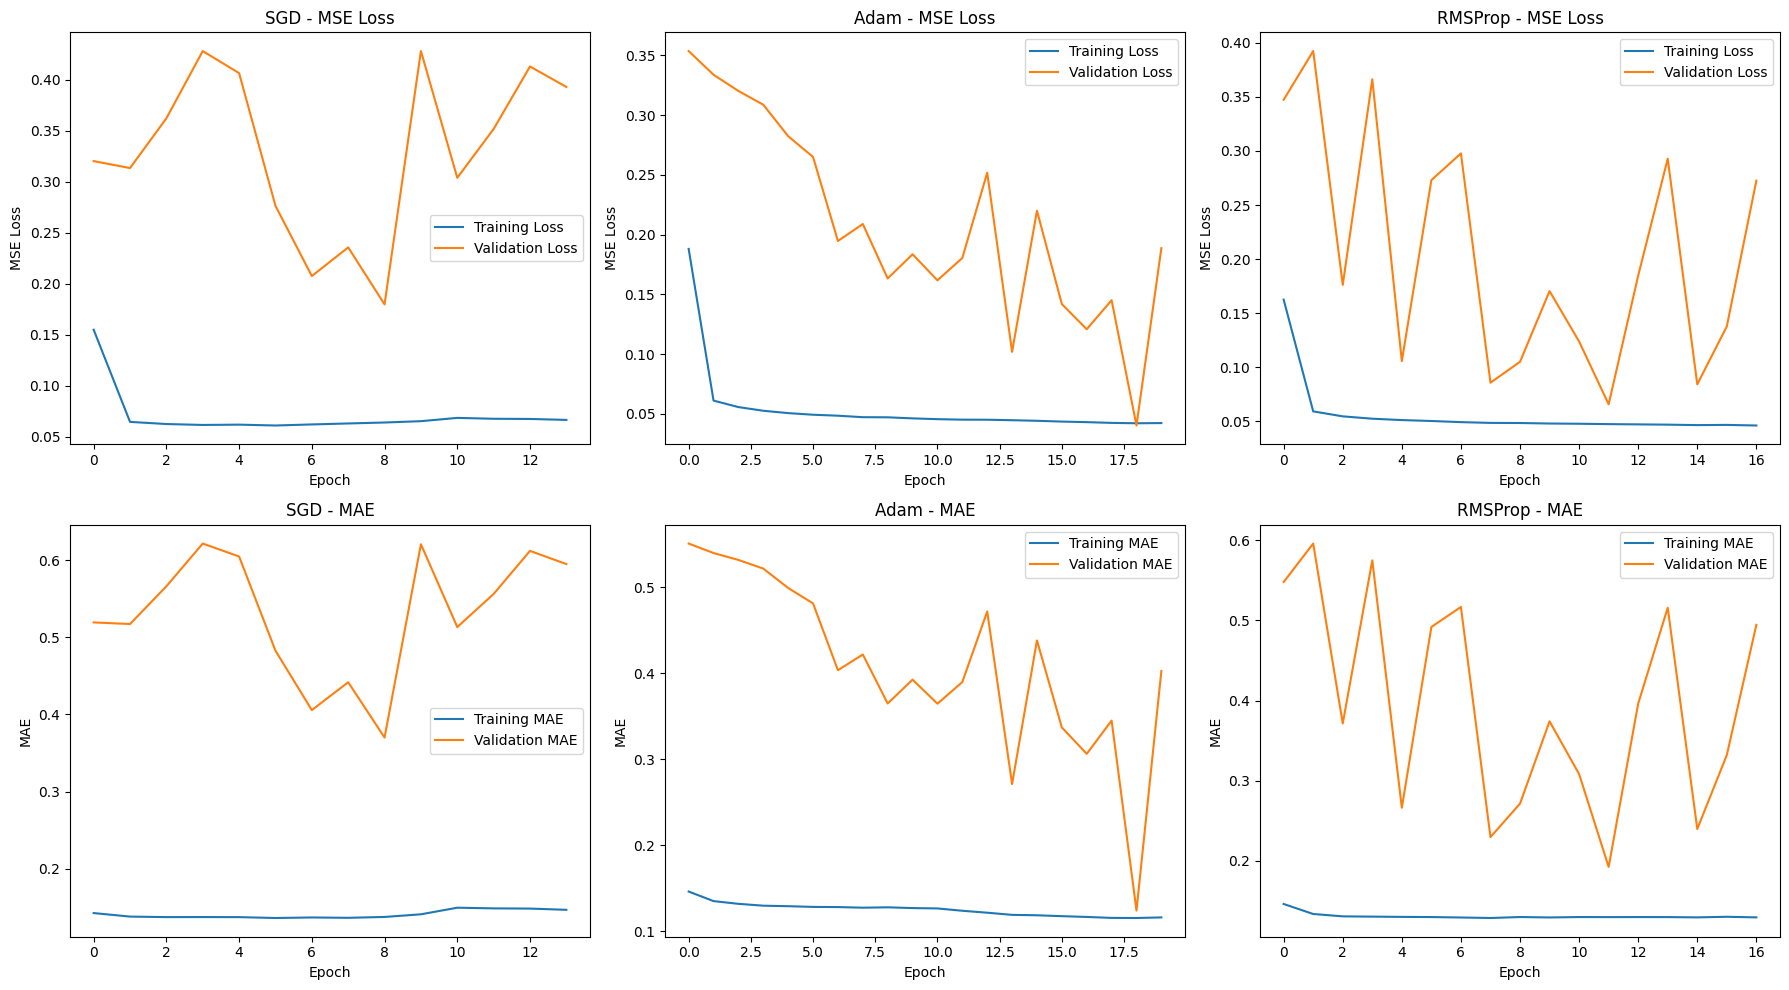

In [12]:
# Plot Training Curves
def plot_training_curves(histories):
    """
    Plot training vs validation loss and MAE for different optimizers
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i, (opt, history) in enumerate(histories.items()):
        # Loss
        axes[0, i].plot(history.history['loss'], label='Training Loss')
        axes[0, i].plot(history.history['val_loss'], label='Validation Loss')
        axes[0, i].set_title(f'{opt} - MSE Loss')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('MSE Loss')
        axes[0, i].legend()

        # MAE
        axes[1, i].plot(history.history['mae'], label='Training MAE')
        axes[1, i].plot(history.history['val_mae'], label='Validation MAE')
        axes[1, i].set_title(f'{opt} - MAE')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('MAE')
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

# Plot curves for different optimizers
plot_training_curves(histories)

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Test MSE: 0.0603
Test MAE: 0.2368
Test RMSE: 0.2455


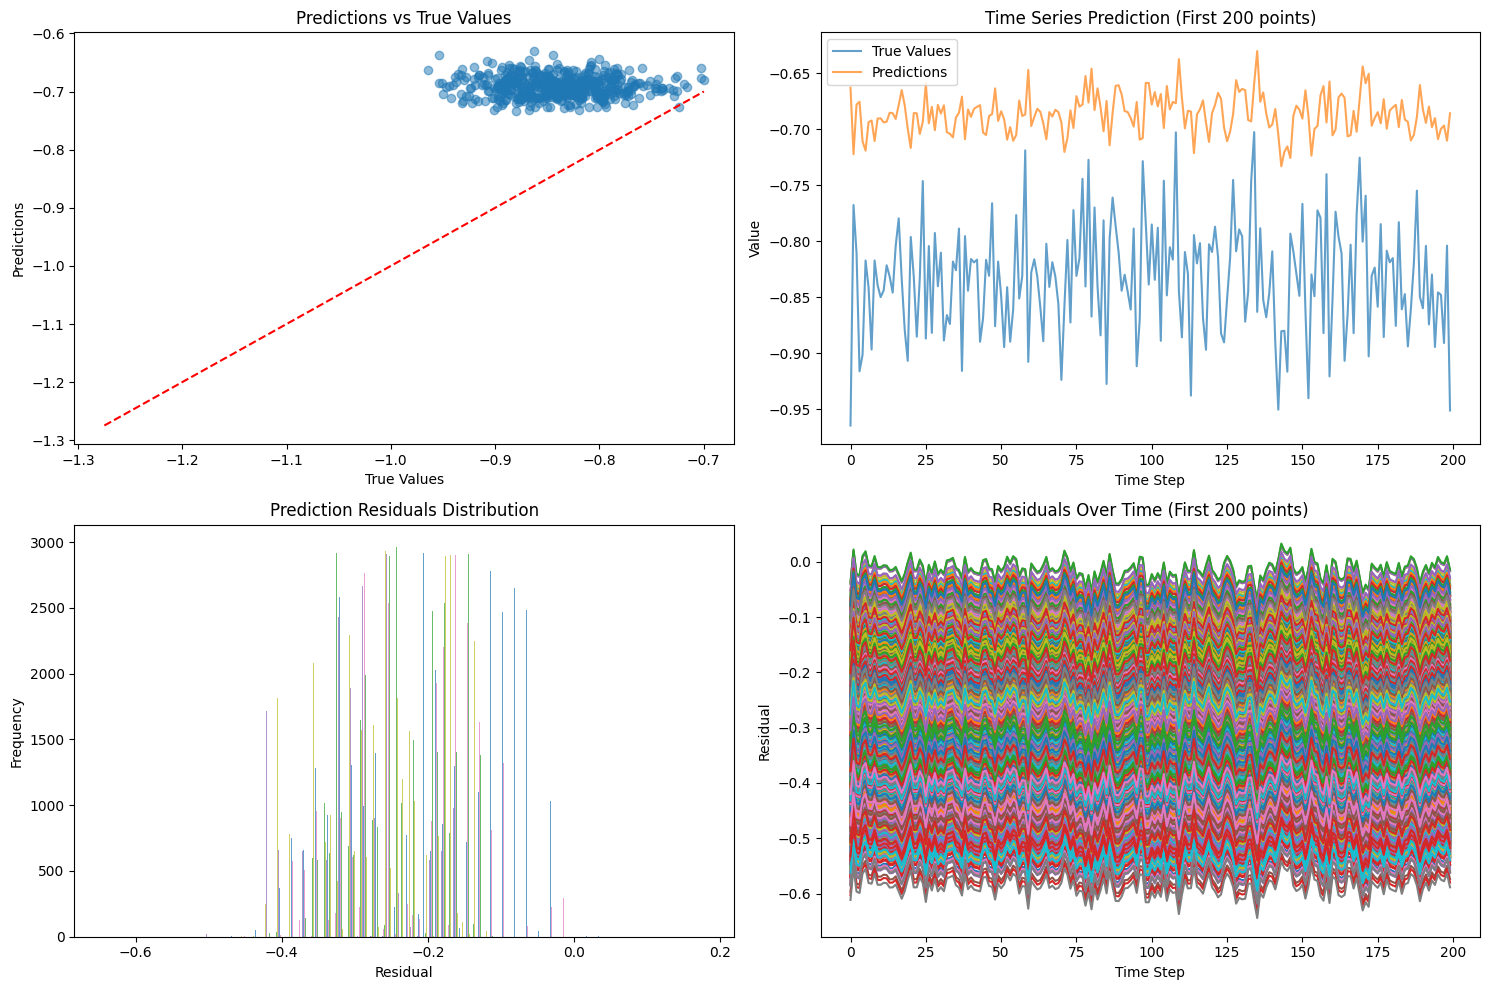

In [10]:
# Model Evaluation
def evaluate_model(model, test_X, test_y, data_mean, data_std):
    """
    Evaluate model performance with MSE, MAE, and prediction visualization
    """
    # Predictions
    predictions = model.predict(test_X)

    # Denormalize predictions and true values
    predictions_denorm = predictions * data_std + data_mean
    true_values_denorm = test_y * data_std + data_mean

    # Calculate metrics
    mse = mean_squared_error(true_values_denorm, predictions_denorm)
    mae = mean_absolute_error(true_values_denorm, predictions_denorm)
    rmse = np.sqrt(mse)

    print(f"Test MSE: {mse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    print(f"Test RMSE: {rmse:.4f}")

    # Plot predictions vs true values
    plt.figure(figsize=(15, 10))

    # Scatter plot
    plt.subplot(2, 2, 1)
    plt.scatter(true_values_denorm[:500], predictions_denorm[:500], alpha=0.5)
    plt.plot([true_values_denorm.min(), true_values_denorm.max()],
             [true_values_denorm.min(), true_values_denorm.max()], 'r--')
    plt.title('Predictions vs True Values')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')

    # Time series plot
    plt.subplot(2, 2, 2)
    plt.plot(true_values_denorm[:200], label='True Values', alpha=0.7)
    plt.plot(predictions_denorm[:200], label='Predictions', alpha=0.7)
    plt.title('Time Series Prediction (First 200 points)')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()

    # Residuals
    residuals = true_values_denorm - predictions_denorm
    plt.subplot(2, 2, 3)
    plt.hist(residuals, bins=50, alpha=0.7)
    plt.title('Prediction Residuals Distribution')
    plt.xlabel('Residual')
    plt.ylabel('Frequency')

    # Residuals over time
    plt.subplot(2, 2, 4)
    plt.plot(residuals[:200])
    plt.title('Residuals Over Time (First 200 points)')
    plt.xlabel('Time Step')
    plt.ylabel('Residual')

    plt.tight_layout()
    plt.show()

    return mse, mae, rmse

# Evaluate the best model
mse, mae, rmse = evaluate_model(best_model, test_X, test_y, data_mean, data_std)

In [20]:
# Save Model
def save_model(model, filename='vanilla_rnn_ts_model.h5'):
    """
    Save the trained model
    """
    model.save(filename)
    print(f"Model saved as {filename}")

# Save the best model
save_model(best_model, 'vanilla_rnn_ts_model.h5')

Model saved as vanilla_rnn_ts_model.h5


## Summary

This notebook implemented a Vanilla RNN (Recurrent Neural Network) using TensorFlow/Keras for time series prediction:

1. **Dataset**: Generated synthetic time series data using sine waves with noise
2. **Preprocessing**: Normalized data, split into train/validation/test sets
3. **Model**: Vanilla RNN with SimpleRNN layers for regression prediction
4. **Training**: Tested SGD, Adam, and RMSProp optimizers
5. **Regularization**: Applied L1/L2 regularization, Dropout, and Early Stopping
6. **Tuning**: Basic hyperparameter tuning for RNN units and learning rate
7. **Visualization**: Training curves, prediction vs true values, residuals analysis
8. **Evaluation**: MSE, MAE, RMSE metrics with detailed prediction analysis
9. **Model Saving**: Saved as .h5 file

The Vanilla RNN model provides a baseline for time series forecasting. You can further improve it by:
- Using more advanced RNN variants (LSTM, GRU)
- Adding bidirectional layers
- Implementing attention mechanisms
- Using convolutional layers before RNN (ConvLSTM)
- Adding more features or external variables
- Experimenting with different sequence lengths and architectures
- Using real-world time series datasets (stock prices, weather data, etc.)